In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Map the Meal Gap data (Feeding America)

In [41]:
mmg_raw = pd.read_excel("data/MMG2025_2019-2023_Data_To_Share.xlsx", sheet_name="County")

In [42]:
#mmg_raw = pd.read_csv("Map the Meal Gap.csv")
mmg_2019 = mmg_raw[mmg_raw['Year'] == 2019].copy()

mmg_2019['County'] = mmg_2019['County, State'].str.split(', ').str[0]

column_mapping = {
    'Overall Food Insecurity Rate': 'pctFoodInsecure',
    '# of Food Insecure Persons Overall': 'numFoodInsecure',
    'Food Insecurity Rate among Black Persons (all ethnicities)': 'pctBlackFoodInsecure',
    'Food Insecurity Rate among Hispanic Persons (any race)': 'pctLatineFoodInsecure',
    'Food Insecurity Rate among White, non-Hispanic Persons': 'pctWhiteFoodInsecure',
    'SNAP Threshold': 'SNAPthreshold',
    '% FI ≤ SNAP Threshold': 'pctFIbelowSNAP',
    '% FI > SNAP Threshold': 'pctFIaboveSNAP',
    'Child Food Insecurity Rate': 'pctKidsFoodInsecure',
    '# of Food Insecure Children': 'numKidsFoodInsecure',
    '% food insecure children in HH w/ HH incomes below 185 FPL': 'pctKidsIncomeBelow185',
    '% food insecure children in HH w/ HH incomes above 185 FPL': 'pctKidsIncomeAbove185',
    'Cost Per Meal': 'costPerMeal',
    'Weighted weekly $ needed by FI': 'weeklyFoodBudget',
    'Weighted Annual Food Budget Shortfall': 'weeklyBudgetFoodInsecureByPop',
    'Rural-Urban Continuum Code (2013)': 'rangeRuralUrban',
    'Census Region': 'USstateRegion'
}

mmg_2019 = mmg_2019.rename(columns=column_mapping)

final_columns = [
    'FIPS', 'State', 'County', 'pctFoodInsecure', 'numFoodInsecure',
    'pctBlackFoodInsecure', 'pctLatineFoodInsecure', 'pctWhiteFoodInsecure',
    'SNAPthreshold', 'pctFIbelowSNAP', 'pctFIaboveSNAP',
    'pctKidsFoodInsecure', 'numKidsFoodInsecure',
    'pctKidsIncomeBelow185', 'pctKidsIncomeAbove185',
    'costPerMeal', 'weeklyFoodBudget', 'weeklyBudgetFoodInsecureByPop',
    'rangeRuralUrban', 'USstateRegion'
]

meal_gap = mmg_2019[final_columns]
meal_gap.to_csv("data/Meal_Gap_2019.csv", index=False)
meal_gap.head()

,FIPS,State,County,pctFoodInsecure,numFoodInsecure,pctBlackFoodInsecure,pctLatineFoodInsecure,pctWhiteFoodInsecure,SNAPthreshold,pctFIbelowSNAP,pctFIaboveSNAP,pctKidsFoodInsecure,numKidsFoodInsecure,pctKidsIncomeBelow185,pctKidsIncomeAbove185,costPerMeal,weeklyFoodBudget,weeklyBudgetFoodInsecureByPop,rangeRuralUrban,USstateRegion
0,1001,AL,Autauga County,0.157,8670.0,0.26,NaN,0.12,1.3,0.486,0.514,0.196,2590.0,0.69,0.31,3.00,16.88,4439000.0,2.0,South
5,1003,AL,Baldwin County,0.134,28590.0,0.26,0.10,0.11,1.3,0.391,0.609,0.144,6680.0,0.79,0.21,3.66,20.63,17895000.0,3.0,South
10,1005,AL,Barbour County,0.207,5250.0,0.34,NaN,0.14,1.3,0.663,0.337,0.324,1720.0,0.72,0.28,3.11,17.51,2788000.0,6.0,South
15,1007,AL,Bibb County,0.163,3680.0,0.28,NaN,0.14,1.3,0.478,0.522,0.218,1010.0,0.89,0.11,2.96,16.68,1861000.0,1.0,South
20,1009,AL,Blount County,0.145,8380.0,0.14,0.11,0.12,1.3,0.462,0.538,0.154,2060.0,1.00,0.00,3.04,17.14,4357000.0,1.0,South


# Combine Data on FIPS

In [43]:
mmg = pd.read_csv("data/Meal_Gap_2019.csv", dtype={'FIPS': str})
fara = pd.read_csv('data/Food Access Research Atlas.csv')

mmg['FIPS'] = mmg['FIPS'].str.zfill(5)
fara['CensusTract'] = fara['CensusTract'].astype(str).str.zfill(11)
fara['county_fips'] = fara['CensusTract'].str[:5]

text_cols = {'CensusTract', 'State', 'County', 'county_fips'}
share_cols = [c for c in fara.columns if c.lower().endswith('share')]

weighted_mean_cols = [c for c in ['PovertyRate', 'MedianFamilyIncome', 'PCTGQTRS']
                      if c in fara.columns]

sum_cols = [c for c in fara.select_dtypes('number').columns
            if c not in share_cols + weighted_mean_cols and c not in text_cols]

county = fara.groupby('county_fips')[sum_cols].sum(min_count=1)
county['n_tracts'] = fara.groupby('county_fips').size()

for col in weighted_mean_cols:
    g = fara.dropna(subset=[col, 'Pop2010'])
    county[col] = g.groupby('county_fips').apply(
        lambda x: np.average(x[col], weights=x['Pop2010'])
                  if x['Pop2010'].sum() > 0 else np.nan
    )

for sc in share_cols:
    base = sc[:-len('share')]
    if base not in county.columns:
        continue
    denom = 'OHU2010' if 'hunv' in base.lower() else 'Pop2010'
    if denom in county.columns:
        county[sc] = np.where(county[denom] > 0, county[base] / county[denom], np.nan)

meta = fara.groupby('county_fips').agg(State_FARA=('State', 'first'),
                                        County_FARA=('County', 'first'))
county = meta.join(county).reset_index()

merged = mmg.merge(county, left_on='FIPS', right_on='county_fips', how='left')

merged.head()

,FIPS,State,County,pctFoodInsecure,numFoodInsecure,pctBlackFoodInsecure,pctLatineFoodInsecure,pctWhiteFoodInsecure,SNAPthreshold,pctFIbelowSNAP,...,laseniors20share,lawhite20share,lablack20share,laasian20share,lanhopi20share,laaian20share,laomultir20share,lahisp20share,lahunv20share,lasnap20share
0,01001,AL,Autauga County,0.157,8670.0,0.26,NaN,0.12,1.3,0.486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01003,AL,Baldwin County,0.134,28590.0,0.26,0.10,0.11,1.3,0.391,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01005,AL,Barbour County,0.207,5250.0,0.34,NaN,0.14,1.3,0.663,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01007,AL,Bibb County,0.163,3680.0,0.28,NaN,0.14,1.3,0.478,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01009,AL,Blount County,0.145,8380.0,0.14,0.11,0.12,1.3,0.462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Standardize Numerical Values

In [44]:
def strip_pct(series, dtype):
    if series.dtype == object:
        return series.str.replace('%', '').astype(dtype)
    return series.astype(dtype)

merged['pctFoodInsecure'] = strip_pct(merged['pctFoodInsecure'], 'float')
merged['pctBlackFoodInsecure'] = strip_pct(merged['pctBlackFoodInsecure'], 'float')
merged['pctLatineFoodInsecure'] = strip_pct(merged['pctLatineFoodInsecure'], 'float')
merged['pctWhiteFoodInsecure'] = strip_pct(merged['pctWhiteFoodInsecure'], 'float')
merged['pctKidsFoodInsecure'] = strip_pct(merged['pctKidsFoodInsecure'], 'float')

merged['SNAPthreshold'] = strip_pct(merged['SNAPthreshold'], 'float')
merged['pctFIbelowSNAP'] = strip_pct(merged['pctFIbelowSNAP'], 'float')
merged['pctFIaboveSNAP'] = strip_pct(merged['pctFIaboveSNAP'], 'float')
merged['pctKidsIncomeBelow185'] = strip_pct(merged['pctKidsIncomeBelow185'], 'float')
merged['pctKidsIncomeAbove185'] = strip_pct(merged['pctKidsIncomeAbove185'], 'float')

merged['rangeRuralUrban'] = merged['rangeRuralUrban'].astype('int')

In [45]:
merged['numFoodInsecure'] = merged['numFoodInsecure'].apply(lambda x: int(float(str(x).replace(",", ""))) if pd.notna(x) else x)
merged['numKidsFoodInsecure'] = merged['numKidsFoodInsecure'].apply(lambda x: int(float(str(x).replace(",", ""))) if pd.notna(x) else x)

In [46]:
def strip_dollar(series, dtype):
    if series.dtype == object:
        return series.str.replace('$', '').astype(dtype)
    return series.astype(dtype)

merged['costPerMeal'] = strip_dollar(merged['costPerMeal'], 'float')
merged['weeklyFoodBudget'] = strip_dollar(merged['weeklyFoodBudget'], 'float')

merged['weeklyBudgetFoodInsecureByPop'] = merged['weeklyBudgetFoodInsecureByPop'].apply(
    lambda x: int(float(str(x).replace("$", "").replace(",", ""))) if pd.notna(x) else x)

In [47]:
merged.head()

,FIPS,State,County,pctFoodInsecure,numFoodInsecure,pctBlackFoodInsecure,pctLatineFoodInsecure,pctWhiteFoodInsecure,SNAPthreshold,pctFIbelowSNAP,...,laseniors20share,lawhite20share,lablack20share,laasian20share,lanhopi20share,laaian20share,laomultir20share,lahisp20share,lahunv20share,lasnap20share
0,01001,AL,Autauga County,0.157,8670,0.26,NaN,0.12,1.3,0.486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01003,AL,Baldwin County,0.134,28590,0.26,0.10,0.11,1.3,0.391,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01005,AL,Barbour County,0.207,5250,0.34,NaN,0.14,1.3,0.663,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01007,AL,Bibb County,0.163,3680,0.28,NaN,0.14,1.3,0.478,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01009,AL,Blount County,0.145,8380,0.14,0.11,0.12,1.3,0.462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Create CSV (merged, not cleaned)

In [48]:
merged.to_csv('data/MMG_FARA_2019_county.csv', index=False)

## Look at the Data, NaN Values

In [49]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3142 entries, 0 to 3141
Columns: 168 entries, FIPS to lasnap20share
dtypes: float64(138), int32(1), int64(22), object(7)
memory usage: 4.0+ MB


In [50]:
merged.describe()

,pctFoodInsecure,numFoodInsecure,pctBlackFoodInsecure,pctLatineFoodInsecure,pctWhiteFoodInsecure,SNAPthreshold,pctFIbelowSNAP,pctFIaboveSNAP,pctKidsFoodInsecure,numKidsFoodInsecure,...,laseniors20share,lawhite20share,lablack20share,laasian20share,lanhopi20share,laaian20share,laomultir20share,lahisp20share,lahunv20share,lasnap20share
count,3142.000000,3.142000e+03,1531.000000,1776.000000,3101.000000,3142.000000,3142.000000,3142.000000,3142.000000,3142.000000,...,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000
mean,0.131009,1.176708e+04,0.223984,0.178440,0.110068,1.589704,0.599794,0.400206,0.179019,3594.633991,...,0.020066,0.087715,0.000685,0.000490,0.000067,0.008356,0.005860,0.011916,0.006492,0.004030
std,0.037171,3.629201e+04,0.063984,0.040555,0.033340,0.301186,0.139929,0.139929,0.057171,11781.347667,...,0.048143,0.204911,0.004236,0.005077,0.000403,0.045638,0.020339,0.051261,0.032021,0.011477
min,0.029000,1.000000e+01,0.010000,0.040000,0.020000,1.300000,0.141000,0.000000,0.014000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.105000,1.460000e+03,0.190000,0.150000,0.090000,1.300000,0.505000,0.307000,0.141000,440.000000,...,0.000120,0.000558,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.129000,3.540000e+03,0.230000,0.180000,0.110000,1.600000,0.592000,0.408000,0.174000,1040.000000,...,0.001959,0.008638,0.000000,0.000000,0.000000,0.000011,0.000264,0.000229,0.000147,0.000313
75%,0.156000,8.705000e+03,0.270000,0.210000,0.130000,2.000000,0.693000,0.495000,0.214000,2550.000000,...,0.013693,0.057224,0.000109,0.000131,0.000000,0.000936,0.002606,0.002795,0.001959,0.002520
max,0.294000,1.079900e+06,0.510000,0.360000,0.420000,2.000000,1.000000,0.859000,0.439000,321690.000000,...,0.289209,0.991632,0.086379,0.142311,0.006948,0.650521,0.253564,0.656628,0.468354,0.109251


Text(0.5, 1.0, 'Distribution of Food Insecurity Rate')

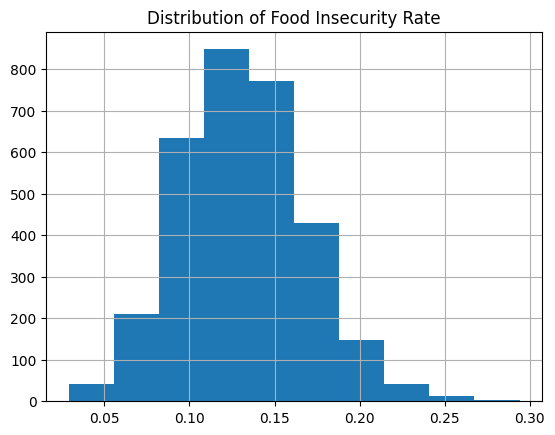

In [51]:
merged['pctFoodInsecure'].hist()
plt.title('Distribution of Food Insecurity Rate')

In [52]:
merged.isna().sum()

FIPS                   0
State                  0
County                 0
pctFoodInsecure        0
numFoodInsecure        0
                    ... 
laaian20share       2292
laomultir20share    2292
lahisp20share       2292
lahunv20share       2292
lasnap20share       2292
Length: 168, dtype: int64

In [53]:
print(merged.columns.tolist())

['FIPS', 'State', 'County', 'pctFoodInsecure', 'numFoodInsecure', 'pctBlackFoodInsecure', 'pctLatineFoodInsecure', 'pctWhiteFoodInsecure', 'SNAPthreshold', 'pctFIbelowSNAP', 'pctFIaboveSNAP', 'pctKidsFoodInsecure', 'numKidsFoodInsecure', 'pctKidsIncomeBelow185', 'pctKidsIncomeAbove185', 'costPerMeal', 'weeklyFoodBudget', 'weeklyBudgetFoodInsecureByPop', 'rangeRuralUrban', 'USstateRegion', 'county_fips', 'State_FARA', 'County_FARA', 'Urban', 'Pop2010', 'OHU2010', 'GroupQuartersFlag', 'NUMGQTRS', 'LILATracts_1And10', 'LILATracts_halfAnd10', 'LILATracts_1And20', 'LILATracts_Vehicle', 'HUNVFlag', 'LowIncomeTracts', 'LA1and10', 'LAhalfand10', 'LA1and20', 'LATracts_half', 'LATracts1', 'LATracts10', 'LATracts20', 'LATractsVehicle_20', 'LAPOP1_10', 'LAPOP05_10', 'LAPOP1_20', 'LALOWI1_10', 'LALOWI05_10', 'LALOWI1_20', 'lapophalf', 'lalowihalf', 'lakidshalf', 'laseniorshalf', 'lawhitehalf', 'lablackhalf', 'laasianhalf', 'lanhopihalf', 'laaianhalf', 'laomultirhalf', 'lahisphalf', 'lahunvhalf', 'l

In [54]:
nan_counts = merged.isna().sum()

nan_counts_sorted = nan_counts.sort_values(ascending=False)
print(nan_counts_sorted.head(10))

lasnap20share    2292
lapop20share     2292
laseniors20      2292
lawhite20        2292
lablack20        2292
laasian20        2292
lanhopi20        2292
laaian20         2292
laomultir20      2292
lahisp20         2292
dtype: int64


In [55]:
columns_with_2292_nans = nan_counts[(nan_counts < 2292) & (nan_counts > 0)].index.tolist()
print(columns_with_2292_nans)

['pctBlackFoodInsecure', 'pctLatineFoodInsecure', 'pctWhiteFoodInsecure', 'NUMGQTRS', 'LAPOP1_10', 'LAPOP05_10', 'LAPOP1_20', 'LALOWI1_10', 'LALOWI05_10', 'LALOWI1_20', 'lapop1', 'lalowi1', 'lakids1', 'laseniors1', 'lawhite1', 'lablack1', 'laasian1', 'lanhopi1', 'laaian1', 'laomultir1', 'lahisp1', 'lahunv1', 'lasnap1', 'lapop10', 'lalowi10', 'lakids10', 'laseniors10', 'lawhite10', 'lablack10', 'laasian10', 'lanhopi10', 'laaian10', 'laomultir10', 'lahisp10', 'lahunv10', 'lasnap10', 'TractLOWI', 'TractKids', 'TractSeniors', 'TractWhite', 'TractBlack', 'TractAsian', 'TractNHOPI', 'TractAIAN', 'TractOMultir', 'TractHispanic', 'TractHUNV', 'TractSNAP', 'PovertyRate', 'MedianFamilyIncome', 'PCTGQTRS', 'lapop1share', 'lalowi1share', 'lakids1share', 'laseniors1share', 'lawhite1share', 'lablack1share', 'laasian1share', 'lanhopi1share', 'laaian1share', 'laomultir1share', 'lahisp1share', 'lahunv1share', 'lasnap1share', 'lapop10share', 'lalowi10share', 'lakids10share', 'laseniors10share', 'lawhite

In [56]:
columns_with_1_nans = nan_counts[nan_counts == 1].index.tolist()
print(columns_with_1_nans)

['PovertyRate']


In [57]:
columns_with_2_to_10_nans = nan_counts[(nan_counts > 1) & (nan_counts <= 10)].index.tolist()
print(columns_with_2_to_10_nans)

['NUMGQTRS', 'lapop1', 'lalowi1', 'lakids1', 'laseniors1', 'lawhite1', 'lablack1', 'laasian1', 'lanhopi1', 'laaian1', 'laomultir1', 'lahisp1', 'lahunv1', 'lasnap1', 'TractLOWI', 'TractKids', 'TractSeniors', 'TractWhite', 'TractBlack', 'TractAsian', 'TractNHOPI', 'TractAIAN', 'TractOMultir', 'TractHispanic', 'TractHUNV', 'TractSNAP', 'MedianFamilyIncome', 'PCTGQTRS', 'lapop1share', 'lalowi1share', 'lakids1share', 'laseniors1share', 'lawhite1share', 'lablack1share', 'laasian1share', 'lanhopi1share', 'laaian1share', 'laomultir1share', 'lahisp1share', 'lahunv1share', 'lasnap1share']
